In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/insurance.csv')

# Programmatically separate columns by data type
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")

# Quick sanity check for missing values and exact data types
display(df.info())

Numerical Columns (4): ['age', 'bmi', 'children', 'charges']
Categorical Columns (3): ['sex', 'smoker', 'region']
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


C:\Users\kau_shal\AppData\Local\Temp\ipykernel_15676\3894918624.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


None

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Load the Medical Insurance Costs dataset
# Adjust path if your working directory differs
df = pd.read_csv('../data/insurance.csv') 

# Isolate numerical features
num_cols = ['age', 'bmi', 'children', 'charges']

# Calculate metrics for each feature
metrics = []
for col in num_cols:
    data = df[col].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    
    metrics.append({
        'Feature': col,
        'Mean': data.mean(),
        'Median': data.median(),
        'Std Dev': data.std(),
        'IQR': q3 - q1,
        'Skewness': skew(data, bias=False),
        'Kurtosis': kurtosis(data, bias=False)
    })

# Format and display as a clean table
descriptive_df = pd.DataFrame(metrics)
display(descriptive_df)

,Feature,Mean,Median,Std Dev,IQR,Skewness,Kurtosis
0,age,39.207025,39.000,14.049960,24.000000,0.055673,-1.245088
1,bmi,30.663397,30.400,6.098187,8.397500,0.284047,-0.050732
2,children,1.094918,1.000,1.205493,2.000000,0.938380,0.202454
3,charges,13270.422265,9382.033,12110.011237,11899.625365,1.515880,1.606299


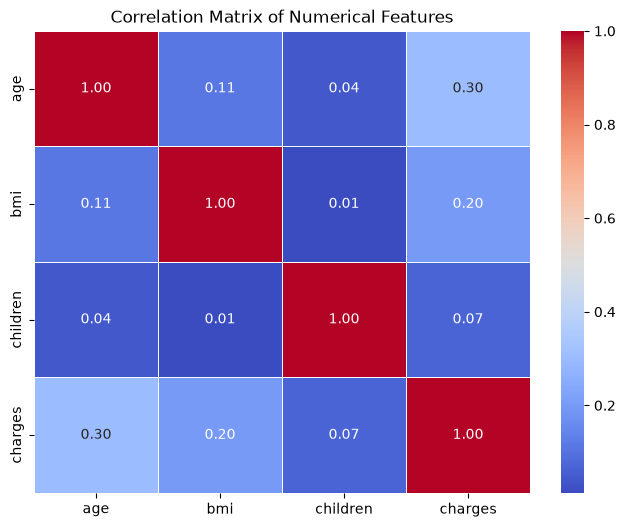

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Isolate numerical columns
num_df = df[['age', 'bmi', 'children', 'charges']]
corr_matrix = num_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

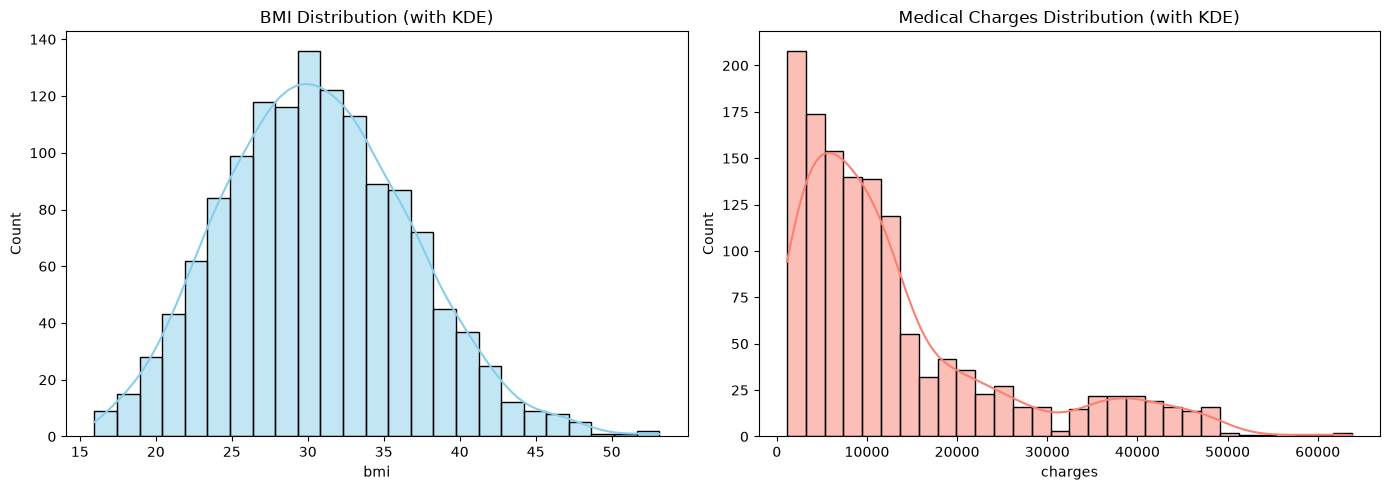

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot for BMI
sns.histplot(df['bmi'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('BMI Distribution (with KDE)')

# Plot for Charges
sns.histplot(df['charges'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Medical Charges Distribution (with KDE)')

plt.tight_layout()
plt.show()

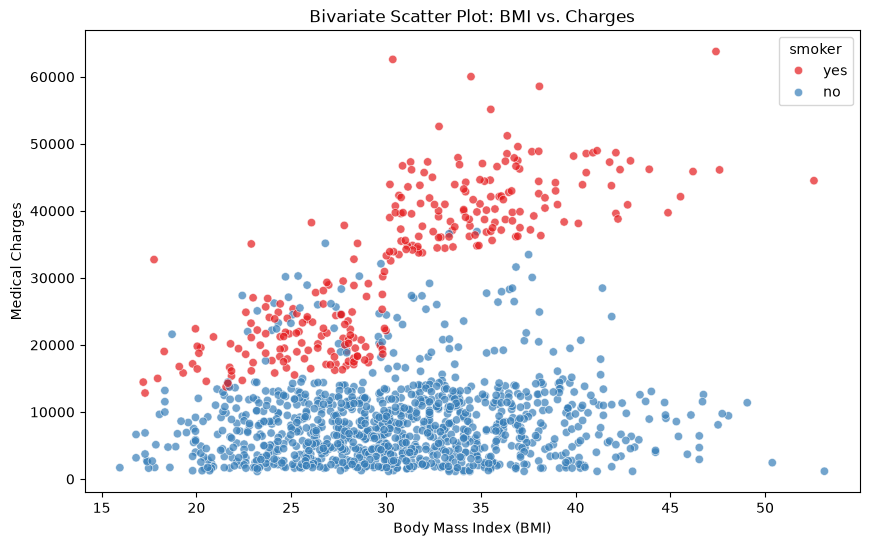

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('Bivariate Scatter Plot: BMI vs. Charges')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Medical Charges')
plt.show()

In [8]:
import pandas as pd
import scipy.stats as stats

df = pd.read_csv('../data/insurance.csv')

# Isolate the continuous metric for the two groups
smokers = df[df['smoker'] == 'yes']['charges'].dropna()
non_smokers = df[df['smoker'] == 'no']['charges'].dropna()

alpha = 0.05

# 1. Check Normality (Shapiro-Wilk)
stat_s, p_shapiro_s = stats.shapiro(smokers)
stat_ns, p_shapiro_ns = stats.shapiro(non_smokers)
is_normal = (p_shapiro_s > alpha) and (p_shapiro_ns > alpha)

# 2. Check Equal Variance (Levene's Test)
stat_l, p_levene = stats.levene(smokers, non_smokers)
equal_var = p_levene > alpha

# 3. Conditional Test Execution
if is_normal:
    stat, p_val = stats.ttest_ind(smokers, non_smokers, equal_var=equal_var)
    test_name = "Two-Sample t-test" if equal_var else "Welch's t-test"
else:
    stat, p_val = stats.mannwhitneyu(smokers, non_smokers, alternative="two-sided")
    test_name = "Mann-Whitney U Test"

# 4. Final Conclusion
conclusion = "Reject H0" if p_val < alpha else "Fail to Reject H0"

print(f"--- Hypothesis Test 1 ---")
print(f"Normality met: {is_normal} | Equal Variance met: {equal_var}")
print(f"Selected Test: {test_name}")
print(f"Test Statistic: {stat:.4f}, p-value: {p_val:.4e}")
print(f"Conclusion at alpha={alpha}: {conclusion}")

--- Hypothesis Test 1 ---
Normality met: False | Equal Variance met: False
Selected Test: Mann-Whitney U Test
Test Statistic: 284133.0000, p-value: 5.2702e-130
Conclusion at alpha=0.05: Reject H0


In [9]:
# Group the continuous metric by the 3+ categorical groups
regions = [group for name, group in df.groupby('region')['charges']]

# Execute One-Way ANOVA
f_stat, p_val_anova = stats.f_oneway(*regions)

anova_conclusion = "Reject H0" if p_val_anova < alpha else "Fail to Reject H0"

print(f"--- Hypothesis Test 2 (One-Way ANOVA) ---")
print(f"F-Statistic: {f_stat:.4f}, p-value: {p_val_anova:.4e}")
print(f"Conclusion at alpha={alpha}: {anova_conclusion}")

--- Hypothesis Test 2 (One-Way ANOVA) ---
F-Statistic: 2.9696, p-value: 3.0893e-02
Conclusion at alpha=0.05: Reject H0


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# 1. Load the dataset
df = pd.read_csv('../data/insurance.csv')

# 2. Separate column types
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}\n")

# 3. Compute Descriptive Metrics Table
metrics = []
for col in num_cols:
    data = df[col].dropna()
    q1, q3 = data.quantile([0.25, 0.75])
    
    metrics.append({
        'Feature': col,
        'Mean': data.mean(),
        'Median': data.median(),
        'Std Dev': data.std(),
        'IQR': q3 - q1,
        'Skewness': skew(data, bias=False),
        'Kurtosis': kurtosis(data, bias=False)
    })

desc_df = pd.DataFrame(metrics)
display(desc_df)

Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']



C:\Users\kau_shal\AppData\Local\Temp\ipykernel_15676\4016863002.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


,Feature,Mean,Median,Std Dev,IQR,Skewness,Kurtosis
0,age,39.207025,39.000,14.049960,24.000000,0.055673,-1.245088
1,bmi,30.663397,30.400,6.098187,8.397500,0.284047,-0.050732
2,children,1.094918,1.000,1.205493,2.000000,0.938380,0.202454
3,charges,13270.422265,9382.033,12110.011237,11899.625365,1.515880,1.606299
